# Module 04 Lab: Simulating Spiking Neurons
**ITAI 4374: Neuroscience as a Model for AI** | Houston City College | Spring 2026

---

In this lab, you will build a spiking neuron simulation from scratch. You will implement a Leaky Integrate-and-Fire (LIF) neuron, encode data as spikes, connect a small network, and run experiments.

**How to use this notebook:**
- Read each markdown cell for context and instructions
- Complete the code cells where you see `# YOUR CODE HERE`
- Answer all **Knowledge Check** and **Reflection** questions in the markdown cells provided
- Run cells in order with `Shift+Enter`

> **File naming:** Before you start, rename this notebook:  
> `L04_FirstName_LastName_ITAI4374.ipynb`  
> File → Rename (in Colab)

---
## Part A: Setup and Your First LIF Neuron

### Step 1: Import Libraries
Run this cell to set up your environment. If you see "Setup complete!" you're good to go.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print('Setup complete!')

Setup complete!


### Step 2: The LIF Equation

The Leaky Integrate-and-Fire neuron is the simplest model that captures spiking behavior. Here's the equation in discrete time:

$$V[t+1] = V[t] + dt \cdot \left( \frac{-(V[t] - V_{rest})}{\tau} + \frac{I[t]}{C} \right)$$

Where:
- **V** = membrane potential (the neuron's "voltage")
- **V_rest** = resting potential (what V returns to with no input)
- **τ (tau)** = membrane time constant (how fast voltage leaks away)
- **I** = input current
- **C** = membrane capacitance
- **dt** = time step

Think of it like a **leaky bucket**: current pours in (I), but voltage constantly leaks back toward rest. If enough current accumulates to push V above a **threshold**, the neuron fires a spike and resets.

### Step 3: Define Parameters
Run this cell to set up your neuron's parameters.

In [2]:
# ============ Simulation Parameters ============
dt = 0.001          # Time step (1 ms)
T  = 1.0            # Total simulation time (1 second)
time = np.arange(0, T, dt)  # Time array

# ============ Neuron Parameters ============
V_rest    = -70.0    # Resting potential (mV)
V_thresh  = -55.0    # Spike threshold (mV)
V_reset   = -75.0    # Reset potential after spike (mV)
tau       = 0.020    # Membrane time constant (20 ms)
C         = 1.0      # Membrane capacitance (normalized)

print(f'Simulation: {T}s with {len(time)} time steps')
print(f'Threshold: {V_thresh} mV, Rest: {V_rest} mV')

Simulation: 1.0s with 1000 time steps
Threshold: -55.0 mV, Rest: -70.0 mV


### ✅ Knowledge Check 1
Answer in the cell below:
1. Why is `V_reset` (-75 mV) set *lower* than `V_rest` (-70 mV)? What biological phenomenon does this represent?
2. The time constant `tau` is 20 ms. In plain English, what does this control?

*Your answers here:*

1. After a neuron fires, its voltage briefly drops lower than its normal resting level. This is called hyperpolarization.

Setting V_reset lower than V_rest copies that behavior. It makes the neuron pause before it can fire again. It represents what happens in real neurons when ion channels cause the voltage to dip after a spike.

2. Tau controls how fast the neuron’s voltage changes.

If tau is small, the voltage changes and resets quickly.
If tau is large, the neuron holds onto input longer and changes more slowly.

So tau basically controls how quickly the neuron responds and how long it “remembers” input.

### Step 4: Build the LIF Simulation

Now implement the core simulation loop. You need to:
1. Compute the voltage change (dV) using the LIF equation
2. Update the membrane potential
3. Check if voltage crossed the threshold → if yes, record the spike and reset

**Read the comments carefully — they tell you exactly what to do.**

In [6]:
# ============ Input Current ============
# Constant current injection: 15 nA from t=200ms to t=800ms
I_input = np.zeros(len(time))
I_input[(time >= 0.2) & (time <= 0.8)] = 800.0

# ============ Storage Arrays ============
V = np.zeros(len(time))   # Membrane potential over time
V[0] = V_rest             # Start at resting potential
spikes = []               # Store spike times

# ============ Simulation Loop ============
for t in range(len(time) - 1):

    # TODO 1: Compute voltage change using the LIF equation
    dV = dt * ( -(V[t] - V_rest) / tau + I_input[t] / C )

    # TODO 2: Update the membrane potential
    V[t+1] = V[t] + dV

    # TODO 3: Check if voltage crossed the threshold
    if V[t+1] >= V_thresh:
        spikes.append(time[t+1])
        V[t+1] = V_reset

print(f'Neuron fired {len(spikes)} spikes')

Neuron fired 10 spikes


> **💡 Tip:** If your neuron fires 0 spikes, double-check your dV equation — make sure the signs are right. If it fires thousands, make sure you reset V to `V_reset` (not `V_rest`) after each spike.
>
> **✅ Checkpoint:** Your neuron should fire roughly 10–25 spikes with these parameters.

### Step 5: Visualize the Membrane Potential

Create a plot with two subplots:
- **Top:** Membrane potential over time (with a dashed line at the threshold)
- **Bottom:** Input current over time

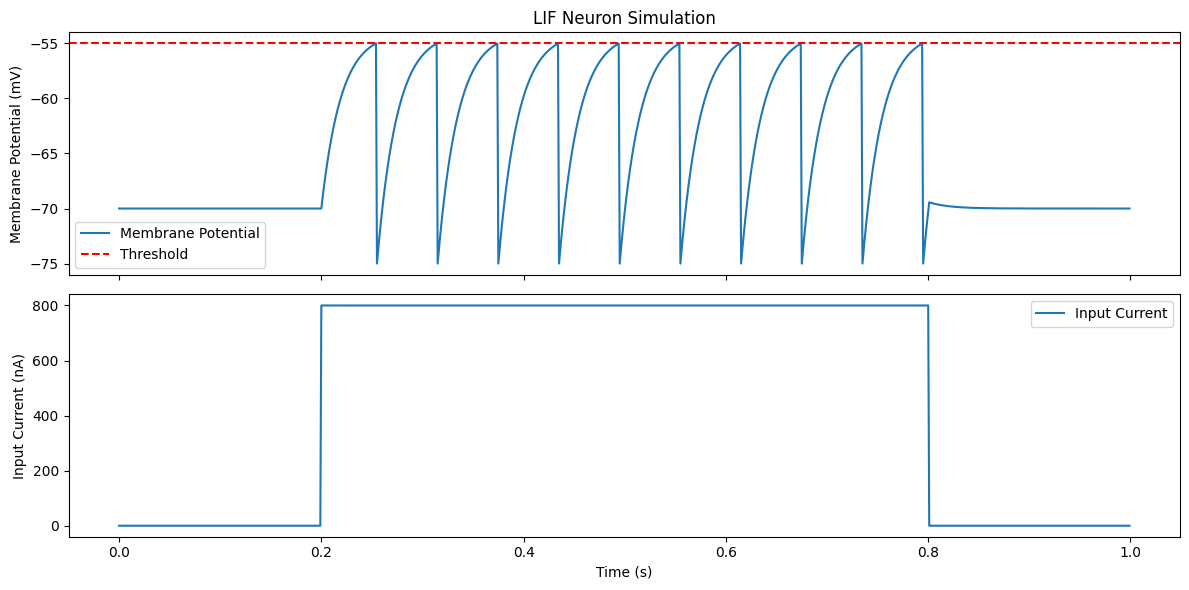

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# TODO 4: Plot membrane potential on ax1
ax1.plot(time, V, label='Membrane Potential')
ax1.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold')

ax1.set_ylabel('Membrane Potential (mV)')
ax1.set_title('LIF Neuron Simulation')
ax1.legend()

# TODO 5: Plot the input current on ax2
ax2.plot(time, I_input, label='Input Current')
ax2.legend()

ax2.set_ylabel('Input Current (nA)')
ax2.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

### ✅ Knowledge Check 2
Look at your plot and answer:
1. What happens to V *between* spikes — does it go straight up, or does it curve? Why?
2. What happens to V *after* the current turns off (t > 0.8s)? Explain why.

*Your answers here:*

1. It curves upward, not straight up.

This happens because of the leak term in the LIF equation. As the voltage increases, the leak pulls it back toward the resting potential. So the voltage rises more slowly over time instead of increasing in a straight line.

2. After the current turns off, the voltage drops back down toward the resting potential.

This happens because there is no more input pushing it up. The leak term causes the membrane potential to slowly return to its resting value.

### 💭 Reflection 1
Look at your membrane potential trace. In the booklet, you learned that biological neurons show similar integrate-and-fire behavior. What aspects of your plot look "realistic" compared to real neurons? What looks overly simplified?

*Your reflection here:*
Some parts of the plot look realistic because the neuron integrates input over time and then fires when it reaches a threshold. After each spike, the voltage drops below resting potential and then slowly rises again. That pattern looks similar to real neurons that show integrate-and-fire behavior.

However, the model is also very simplified. The spikes are all the same shape and happen instantly. In real neurons, spikes have a detailed shape with rising and falling phases. Also, this model does not include things like different ion channels, adaptation, or complex dendrite structure. It only captures the basic idea of voltage building up and then firing.


---
## Part B: Encoding Data as Spikes

Real brains don't receive numbers or pixel values — they receive spikes. To feed data into a spiking neural network, we need to convert regular numbers into spike trains.

The two main strategies are:
- **Rate coding:** Higher values → more spikes per second
- **Temporal coding:** Higher values → earlier spike time

### Step 6: Rate Coding

In rate coding, at each time step we generate a random number between 0 and 1. If the random number is less than the pixel intensity, we emit a spike.

Think of it this way: a value of 0.9 has a 90% chance of spiking at each time step (lots of spikes). A value of 0.1 has only a 10% chance (few spikes).

**Complete the function below:**

In [8]:
def rate_encode(values, num_steps=100):
    """
    Convert an array of values (0 to 1) into spike trains using rate coding.
    
    Args:
        values: 1D numpy array with values between 0 and 1
        num_steps: number of time steps to simulate
    Returns:
        spikes: 2D array (num_steps, len(values)) where 1=spike, 0=no spike
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for t in range(num_steps):
        # TODO 6: Generate random numbers and compare to values
        spikes[t] = (np.random.rand(num_neurons) < values).astype(float)

    return spikes

**Test your function:**

In [9]:
# Test with 5 values of increasing intensity
test_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
test_spikes = rate_encode(test_values, num_steps=200)

# Count spikes per neuron — higher values should produce more spikes
for i, v in enumerate(test_values):
    count = test_spikes[:, i].sum()
    print(f'Value {v:.1f} -> {count:.0f} spikes in 200 steps')

Value 0.1 -> 22 spikes in 200 steps
Value 0.3 -> 61 spikes in 200 steps
Value 0.5 -> 91 spikes in 200 steps
Value 0.7 -> 145 spikes in 200 steps
Value 0.9 -> 182 spikes in 200 steps


> **✅ Checkpoint:** Value 0.9 should have roughly ~180 spikes, value 0.1 roughly ~20. Exact numbers vary (it's random), but the trend should be clear: higher values → more spikes.

### Step 7: Temporal Coding

In temporal coding, information is in **when** a spike happens, not how many. Higher values spike earlier, lower values spike later (or not at all). Think of it as urgency: important signals arrive first.

**Complete the function below:**

In [10]:
def temporal_encode(values, num_steps=100, threshold=0.05):
    """
    Convert values (0 to 1) into spike trains using time-to-first-spike.
    Higher values spike earlier.
    
    Args:
        values: 1D numpy array with values between 0 and 1
        num_steps: number of time steps
        threshold: minimum value to produce a spike
    Returns:
        spikes: 2D array (num_steps, len(values))
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for i in range(num_neurons):
        if values[i] > threshold:
            # TODO 7: Calculate spike time
            spike_time = int((1 - values[i]) * (num_steps - 1))
            spikes[spike_time, i] = 1

    return spikes

### Step 8: Visualize and Compare Both Encodings

Apply both encoding methods to the same data and create **raster plots** — scatter plots where each dot represents a spike.

For a raster plot you need:
```python
times, neurons = np.where(spike_array == 1)
ax.scatter(times, neurons, s=1, color='black')
```

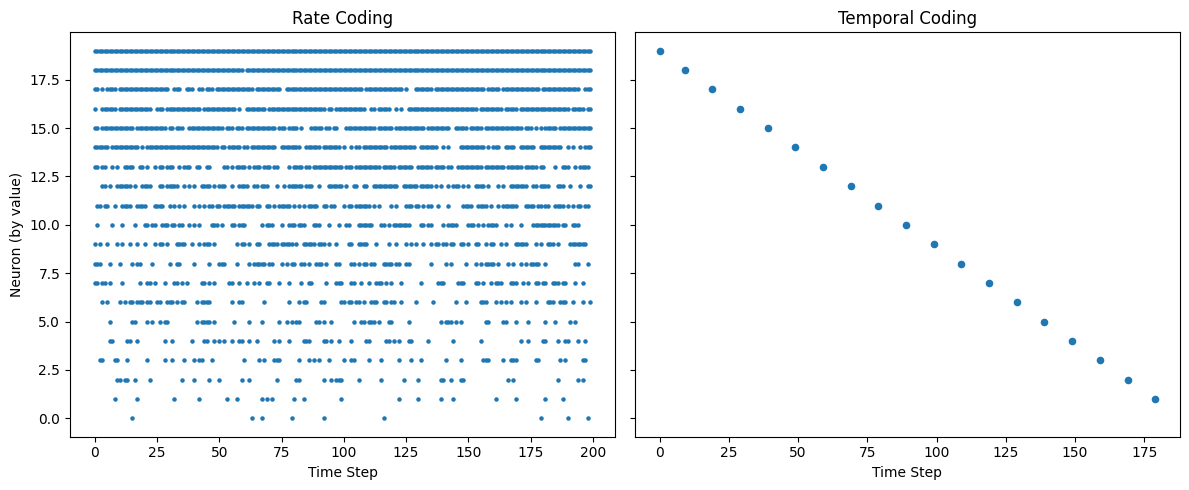

In [11]:
# Create a test signal: 20 values from 0.05 to 1.0
signal = np.linspace(0.05, 1.0, 20)

# Encode with both methods
rate_spks = rate_encode(signal, num_steps=200)
temp_spks = temporal_encode(signal, num_steps=200)

# TODO 8: Create a figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Rate coding raster
times_r, neurons_r = np.where(rate_spks == 1)
ax1.scatter(times_r, neurons_r, s=5)
ax1.set_title('Rate Coding')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Neuron (by value)')

# Temporal coding raster
times_t, neurons_t = np.where(temp_spks == 1)
ax2.scatter(times_t, neurons_t, s=20)
ax2.set_title('Temporal Coding')
ax2.set_xlabel('Time Step')

plt.tight_layout()
plt.show()

> **✅ Checkpoint:** Rate coding raster: scattered dots, denser at top (high-value neurons). Temporal coding raster: a diagonal line — high-value neurons spike on the left, low-value on the right.

### ✅ Knowledge Check 3
1. In rate coding, what information is lost about the original signal? What is preserved?
2. In temporal coding, why might it be *faster* for a downstream neuron to make a decision compared to rate coding?
3. Can you think of a real-world example where timing matters more than frequency? (Hint: sound localization)

*Your answers here:*

1. In rate coding, the exact timing of spikes is lost. We don’t know exactly when each spike happened, only how many occurred over time.

What is preserved is the overall strength of the signal. Higher values still produce more spikes, so the intensity of the signal is kept.

2. In temporal coding, important signals spike earlier. A downstream neuron can react as soon as it sees the first spike instead of waiting to count many spikes over time.

This makes decisions faster because the information is carried in the timing of a single spike rather than in the number of spikes.

3. Sound localization is a good example. The brain determines where a sound is coming from by detecting tiny timing differences between when the sound reaches each ear.

The exact timing matters more than how many sound waves arrive. Even very small differences in arrival time help the brain figure out direction.

### 💭 Reflection 2
Compare your two raster plots. Which encoding would be better for a system that needs to react quickly? Which for precise measurements? The brain uses both strategies in different circuits — why do you think that is?

*Your reflection here:*
Temporal coding would be better for a system that needs to react quickly. The most important signals spike earlier, so a neuron can make a decision as soon as it sees the first spike. It does not have to wait and count many spikes.

Rate coding would be better for precise measurements. Because it uses the number of spikes over time, it can represent small differences in signal strength more accurately, but it takes longer.

The brain likely uses both strategies because different tasks require different types of information. Some situations need fast reactions, while others need accurate measurement. Using both methods allows the brain to balance speed and precision depending on the situation.

---
## Part C: Connect a Mini Spiking Network

A single neuron is interesting, but brains are **networks**. Now you will connect multiple LIF neurons with synaptic weights.

The idea: when neuron A fires a spike, it sends current to neuron B. The amount depends on the **synaptic weight** between them.
- **Positive weight** = excitatory (helps B fire)
- **Negative weight** = inhibitory (prevents B from firing)

### Network Architecture
We'll build a 5-neuron network:
- Neurons 0, 1: **Input** (receive external current)
- Neurons 2, 3: **Hidden** (receive input from 0 and 1)
- Neuron 4: **Output** (receives input from 2 and 3)

In [48]:
# Network parameters
N = 5
T_net = 0.5
time_net = np.arange(0, T_net, dt)
steps = len(time_net)

# Weights (reduced into hidden, smaller into output)
weights = np.zeros((N, N))
weights[0, 2] = 1500.0
weights[1, 3] = 9000.0
weights[2, 4] = 1000.0
weights[3, 4] = 500.0

# External input (only neurons 0 and 1)
I_ext = np.zeros((steps, N))
I_ext[100:400, 0] = 1200.0
I_ext[150:350, 1] = 1200.0

# Storage
V_net = np.full((steps, N), V_rest)
spike_log = [[] for _ in range(N)]

prev_spiked = np.zeros(N, dtype=bool)
just_spiked = np.zeros(N, dtype=bool)

# Synaptic current (shorter lasting than before)
syn = np.zeros(N)
syn_decay = 0.95

# Refractory period (3 ms)
refrac_steps = int(0.003 / dt)
refrac_count = np.zeros(N, dtype=int)

# Simulation loop
for t in range(steps - 1):
    just_spiked[:] = False

    syn *= syn_decay

    for j in range(N):
        if prev_spiked[j]:
            syn += weights[j, :]

    for n in range(N):
        if refrac_count[n] > 0:
            V_net[t+1, n] = V_reset
            refrac_count[n] -= 1
            continue

        I_total = I_ext[t, n] + syn[n]

        dV = dt * ( (-(V_net[t, n] - V_rest) / tau) + (I_total / C) )
        V_net[t+1, n] = V_net[t, n] + dV

        if V_net[t+1, n] >= V_thresh:
            spike_log[n].append(time_net[t+1])
            V_net[t+1, n] = V_reset
            just_spiked[n] = True
            refrac_count[n] = refrac_steps

    prev_spiked[:] = just_spiked

# Print results
for n in range(N):
    print(f'Neuron {n}: {len(spike_log[n])} spikes')

Neuron 0: 11 spikes
Neuron 1: 7 spikes
Neuron 2: 10 spikes
Neuron 3: 28 spikes
Neuron 4: 15 spikes


> **💡 Tip:** For synaptic input, one approach: before the neuron loop at each time step, check which neurons spiked at step `t-1` by seeing if `V_net[t-1, j]` was recently reset (i.e., close to `V_reset`). Or keep a separate `prev_spiked` array.
>
> **✅ Checkpoint:** Input neurons (0, 1) fire the most. Hidden (2, 3) fire next. Output (4) fires last and fewest. If neuron 4 has 0 spikes, try increasing weights slightly.

### Step 10: Visualize Network Activity

Create a raster plot for all 5 neurons, plus a subplot showing the output neuron's membrane potential.

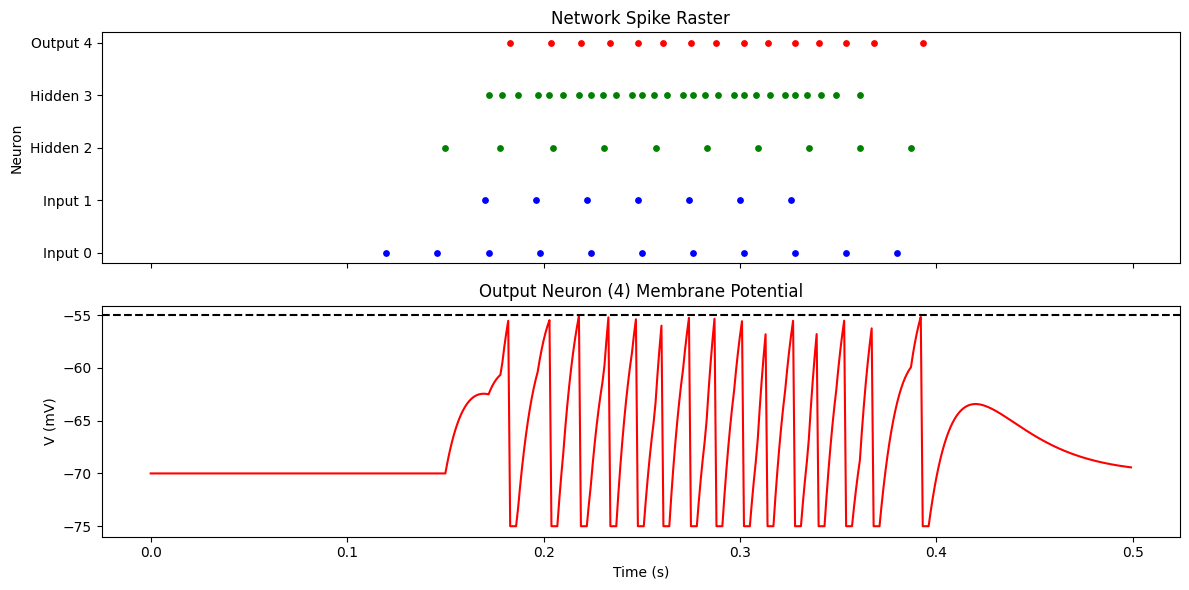

In [49]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Raster plot of all neurons
for n in range(N):
    if n in [0, 1]:
        color = 'blue'      # Input neurons
    elif n in [2, 3]:
        color = 'green'     # Hidden neurons
    else:
        color = 'red'       # Output neuron

    ax1.scatter(spike_log[n], [n] * len(spike_log[n]), s=15, color=color)

ax1.set_ylabel('Neuron')
ax1.set_title('Network Spike Raster')
ax1.set_yticks(range(N))
ax1.set_yticklabels(['Input 0', 'Input 1', 'Hidden 2', 'Hidden 3', 'Output 4'])

# Plot output neuron membrane potential
ax2.plot(time_net, V_net[:, 4], color='red')
ax2.axhline(y=V_thresh, color='black', linestyle='--')

ax2.set_ylabel('V (mV)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Output Neuron (4) Membrane Potential')

plt.tight_layout()
plt.show()

### ✅ Knowledge Check 4
1. Does the output neuron fire at the same rate as the input neurons? Why or why not?
2. What role do the synaptic weights play? What would happen if you doubled them? Halved them?
3. In the brain, not all connections are excitatory. What might happen if you made `weights[3, 4]` negative (inhibitory)?

*Your answers here:*

1. No, the output neuron does not fire at the same rate. It usually fires less.
That is because it only fires when it receives enough combined input from the hidden neurons. It does not get direct external current, so it depends on upstream activity and synaptic strength.

2. Synaptic weights control how strongly one neuron influences another.

If you doubled the weights, downstream neurons would receive stronger input and would fire more often, possibly too much.
If you halved the weights, the input might not be strong enough to reach threshold, and downstream neurons might fire less or not at all.

3. If weights[3, 4] were negative, neuron 3 would suppress neuron 4 instead of exciting it.
This would make neuron 4 fire less often or possibly stop firing entirely. In the brain, inhibition helps control timing, prevent runaway firing, and balance network activity.

---
## Part D: Experiments

Science is about changing things and observing what happens. **Run at least 3** of the experiments below.

For each experiment:
1. What parameter did you change, and to what values?
2. What did you *expect* to happen?
3. What *actually* happened? (Include the plot.)
4. Why does this make sense given the LIF equation?

> ⚠️ **Create new code cells for experiments. Do NOT overwrite your working code above.**

### Experiment Options (pick at least 3)

**Experiment 1: Threshold Sensitivity** — Change `V_thresh` from -55 to -50, then -60. How does firing rate change?

**Experiment 2: Time Constant Effects** — Change `tau` to 0.010, then 0.050. How does the membrane potential shape change between spikes?

**Experiment 3: Varying Input** — Use a ramp current: `I_input = np.linspace(0, 25, len(time))`. How does the firing pattern change over time?

**Experiment 4: Noisy Input** — Add noise: `I_noisy = 15.0 + np.random.randn(len(time)) * 5.0`. Is the spike pattern regular or irregular?

**Experiment 5: Network Inhibition** — Set `weights[3, 4] = -8.0`. How does the output neuron change?

**Experiment 6: f–I Curve** — Sweep input current from 0 to 30. For each, count spikes. Plot current vs spike count.

### Experiment 1: Threshold Sensitivity 
**Parameter changed:** V_thresh was changed from -55 to -50 and -60. 

**Expected result:**  If the threshold is higher (-50), the neuron should fire less.
If the threshold is lower (-60), the neuron should fire more.

V_thresh = -50.0 → 0 spikes
V_thresh = -55.0 → 10 spikes
V_thresh = -60.0 → 24 spikes


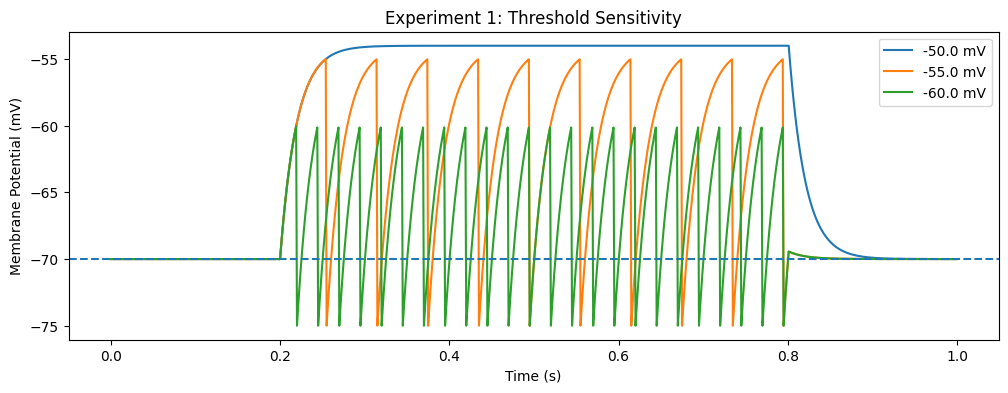

In [50]:
# Experiment 1: Threshold Sensitivity

thresholds = [-50.0, -55.0, -60.0]

plt.figure(figsize=(12, 4))

for thr in thresholds:
    V = np.zeros(len(time))
    V[0] = V_rest
    spikes = []

    for t in range(len(time) - 1):
        dV = dt * ( (-(V[t] - V_rest) / tau) + (I_input[t] / C) )
        V[t+1] = V[t] + dV

        if V[t+1] >= thr:
            spikes.append(time[t+1])
            V[t+1] = V_reset

    print(f'V_thresh = {thr} → {len(spikes)} spikes')
    plt.plot(time, V, label=f'{thr} mV')

plt.axhline(y=V_rest, linestyle='--')
plt.title('Experiment 1: Threshold Sensitivity')
plt.xlabel('Time (s)')
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.show()

**What happened:**  When the threshold was -50, the spike count decreased.
When it was -60, the spike count increased.

**Why it makes sense:**  A lower threshold makes it easier for the voltage to reach the firing level, so the neuron spikes more often. A higher threshold makes it harder to fire.

### Experiment 2: Time Constant Effects
**Parameter changed:**  Tau was changed to 0.010 and 0.050.

**Expected result:**  A smaller tau should make the voltage change faster.
A larger tau should make the voltage change more slowly.

tau = 0.01 → 0 spikes
tau = 0.02 → 10 spikes
tau = 0.05 → 20 spikes


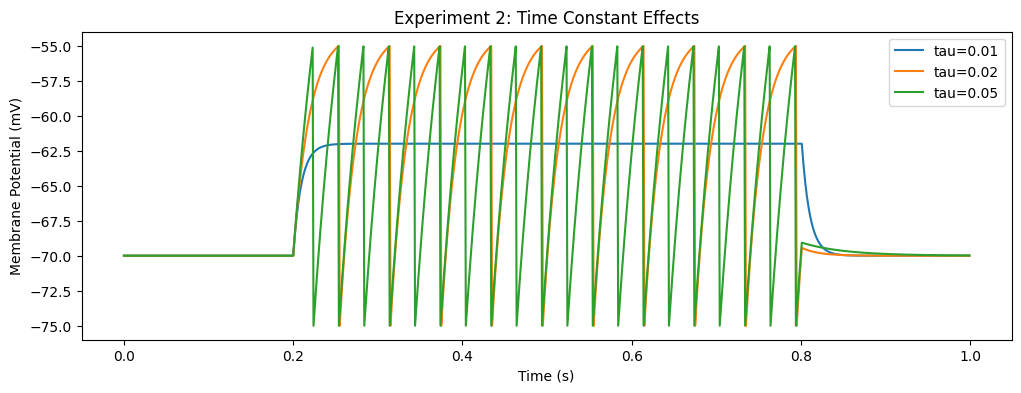

In [51]:
# Experiment 2: Time Constant Effects

taus = [0.010, 0.020, 0.050]

plt.figure(figsize=(12, 4))

for tau_test in taus:
    V = np.zeros(len(time))
    V[0] = V_rest
    spikes = []

    for t in range(len(time) - 1):
        dV = dt * ( (-(V[t] - V_rest) / tau_test) + (I_input[t] / C) )
        V[t+1] = V[t] + dV

        if V[t+1] >= V_thresh:
            spikes.append(time[t+1])
            V[t+1] = V_reset

    print(f'tau = {tau_test} → {len(spikes)} spikes')
    plt.plot(time, V, label=f'tau={tau_test}')

plt.title('Experiment 2: Time Constant Effects')
plt.xlabel('Time (s)')
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.show()

**What happened:**  With tau = 0.010, the voltage rose and fell more quickly.
With tau = 0.050, the voltage changed more slowly and looked smoother.

**Why it makes sense:**  Tau controls how quickly the membrane responds to input and leaks back to rest. Smaller tau means faster response. Larger tau means slower integration.

### Experiment 4: Noisy Input
**Parameter changed:**  Random noise was added to the input current.

**Expected result:**  The spike pattern should become irregular instead of evenly spaced.

Noisy input → 11 spikes


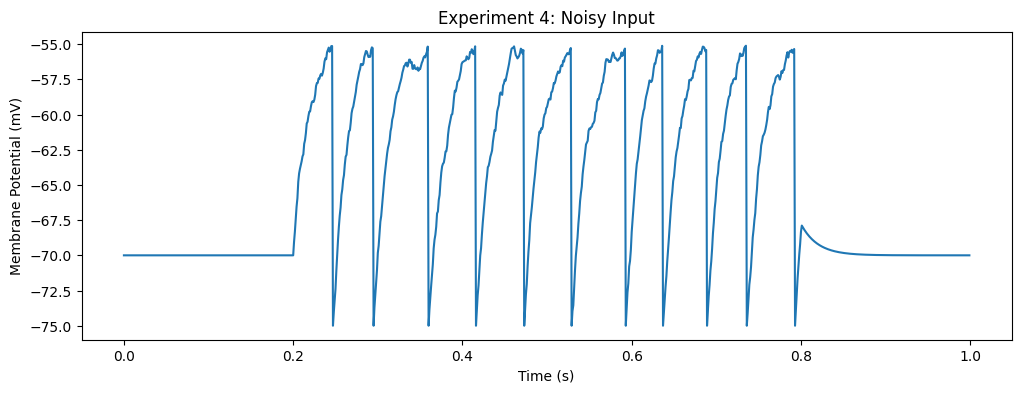

In [52]:
# Experiment 4: Noisy Input

I_noisy = np.zeros(len(time))
noise = 800.0 + np.random.randn(len(time)) * 200.0
I_noisy[(time >= 0.2) & (time <= 0.8)] = noise[(time >= 0.2) & (time <= 0.8)]

V = np.zeros(len(time))
V[0] = V_rest
spikes = []

for t in range(len(time) - 1):
    dV = dt * ( (-(V[t] - V_rest) / tau) + (I_noisy[t] / C) )
    V[t+1] = V[t] + dV

    if V[t+1] >= V_thresh:
        spikes.append(time[t+1])
        V[t+1] = V_reset

print(f'Noisy input → {len(spikes)} spikes')

plt.figure(figsize=(12, 4))
plt.plot(time, V)
plt.title('Experiment 4: Noisy Input')
plt.xlabel('Time (s)')
plt.ylabel('Membrane Potential (mV)')
plt.show()

**What happened:**  The spikes were not evenly spaced anymore. Some spikes happened closer together, and some were farther apart.

**Why it makes sense:**  The noisy input makes the membrane potential fluctuate randomly. Since the voltage reaches threshold at different times, the spike timing becomes irregular.

---
## Part E: Final Reflection

Answer each question thoughtfully. These connect your hands-on experience to the bigger picture from the booklet.

### 💭 Reflection 3
How does changing the membrane time constant (τ) affect firing behavior? What biological property does this represent? (Think about different types of neurons in the brain.)

*Your reflection here:*
Changing the membrane time constant changed how quickly the neuron responded to input. When tau was small, the voltage rose and fell quickly and the neuron reacted faster. When tau was larger, the voltage changed more slowly and the neuron integrated input over a longer time.

Biologically, this represents differences between neuron types. Some neurons respond very quickly to signals, while others integrate input more slowly. Tau reflects how fast or slow a neuron processes information.

### 💭 Reflection 4
Compare your rate coding and temporal coding results. Which encoding preserved more information about the original signal? Why might the brain use both strategies in different circuits?

*Your reflection here:*
Rate coding preserved the overall strength of the signal because higher values produced more spikes. However, it lost the exact timing of each spike. Temporal coding preserved timing information, since higher values spiked earlier, but it did not preserve spike frequency over time.

The brain likely uses both because different tasks need different information. Some circuits need fast decisions based on timing, while others need accurate measurement of signal strength. Using both strategies allows flexibility.

### 💭 Reflection 5
In your mini SNN, what happened when spikes propagated through layers? How does this relate to how information flows through real neural circuits?

*Your reflection here:*
In the mini SNN, spikes moved from input neurons to hidden neurons and then to the output neuron. Each layer depended on the activity of the previous one. If the earlier neurons did not fire enough, the later ones would not fire either.

This is similar to real neural circuits where information flows through layers of connected neurons. Activity in early neurons influences later neurons, and signals are transformed as they move through the network.


### 💭 Reflection 6
The LIF model is a simplification. What does it capture well about real neurons? What important biological features does it miss? (Think: dendrites, neurotransmitters, morphology, adaptation.)

*Your reflection here:* The LIF model captures the basic idea of integration and firing. It shows how voltage builds up over time and resets after reaching a threshold. It also shows the effect of leakage and threshold behavior.

However, it misses many biological details. Real neurons have complex dendrites, different ion channels, neurotransmitters, adaptation effects, and different spike shapes. The LIF model is a simplified mathematical version of much more complex biology.

### 💭 Reflection 7
After building these simulations, what is one thing about biological neural computation that surprised you or changed how you think about artificial intelligence?

*Your reflection here:*
One thing that surprised me was how much behavior can come from such a simple equation. Even with a basic model, we saw realistic firing patterns and network behavior. It changed how I think about artificial intelligence because it showed that simple rules at the neuron level can produce complex behavior when connected in networks.


---
## 🎉 You're Done!

**Before submitting, check:**
- [ ] All code cells run without errors and outputs are visible
- [ ] All Knowledge Check questions are answered
- [ ] All Reflection prompts are answered
- [ ] At least 3 experiments completed with observations
- [ ] Notebook is named: `L04_FirstName_LastName_ITAI4374.ipynb`

**Submit:** Download this notebook (File → Download → Download .ipynb) and upload to Canvas.